In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
#Check Missing Values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
#Fill Missing Values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

In [10]:
#Remove Duplicate Rows
df.drop_duplicates(inplace=True)

In [12]:
# Remove extra spaces
df['date_added'] = df['date_added'].str.strip()

# Convert to datetime
df['date_added'] = pd.to_datetime(df['date_added'])

In [13]:
#Total Movies vs TV Shows
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

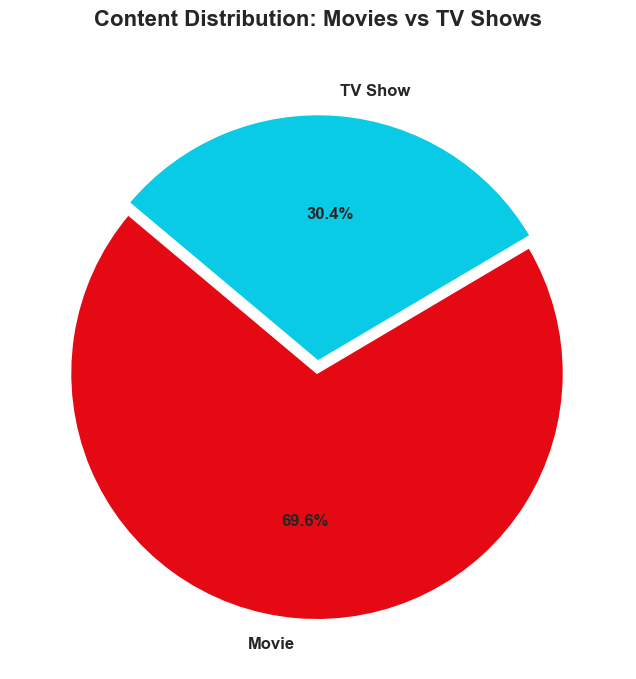

In [58]:
#Visualization

# 1. Prepare the data
counts = df['type'].value_counts()

# 2. Create the pie chart
plt.figure(figsize=(8, 8))
colors = ['#e50914', '#09cbe5'] # Netflix-inspired red and dark grey

plt.pie(counts, 
        labels=counts.index, 
        autopct='%1.1f%%',      # Shows the percentage on the slice
        startangle=140, 
        colors=colors, 
        explode=(0.05, 0),      # Gently pulls the "Movie" slice out
        textprops={'fontsize': 12, 'fontweight': 'bold'})

# 3. Final touches
plt.title("Content Distribution: Movies vs TV Shows", fontsize=16, fontweight='bold', pad=20)
plt.show()

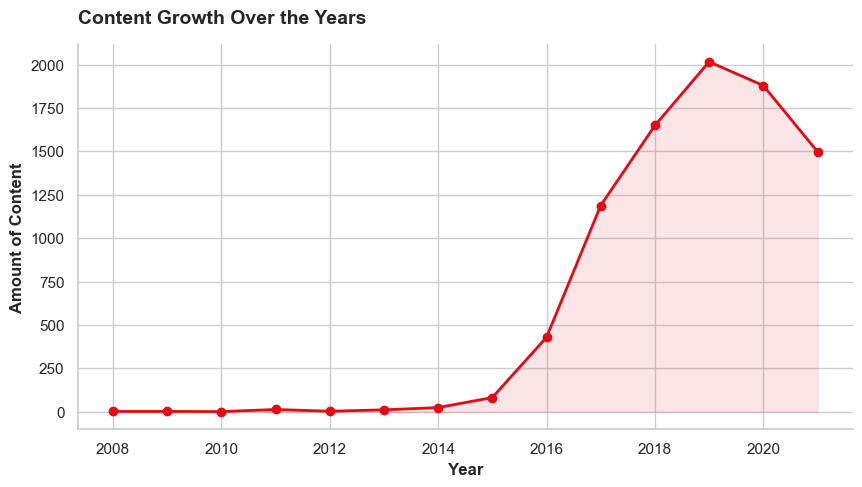

In [27]:
#Content Added Over Years
# Prepare the data
data = df['year_added'].value_counts().sort_index()

# Set style and create the plot
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))

# Plot line with markers
plt.plot(data.index, data.values, marker='o', color='#E50914', linewidth=2, markersize=6)

# Add a professional "Area Chart" fill
plt.fill_between(data.index, data.values, color='#E50914', alpha=0.1)

# Clean up labels
plt.title("Content Growth Over the Years", fontsize=14, fontweight='bold', loc='left', pad=15)
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Amount of Content", fontweight='bold')

sns.despine() # Removes the top and right borders
plt.show()

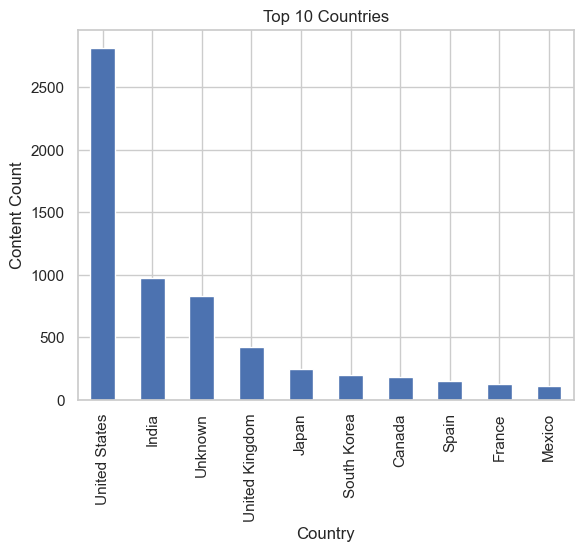

In [28]:
#Top 10 Countries Producing Netflix Content
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Content Count")

plt.show()

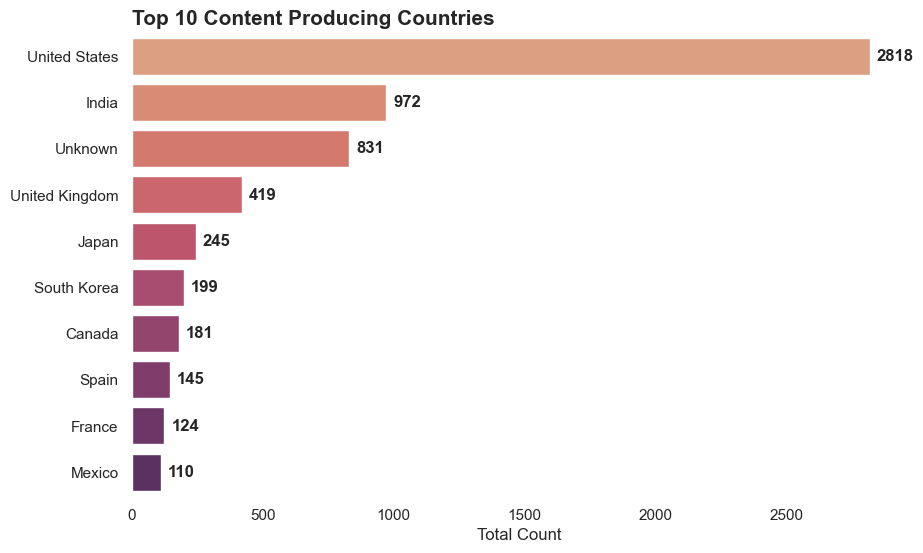

In [30]:
#Top 10 Countries Producing Netflix Content
import seaborn as sns
import matplotlib.pyplot as plt

top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
# Create the plot
ax = sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette="flare", legend=False)

# FIX: Loop through all containers to label every bar
for container in ax.containers:
    ax.bar_label(container, padding=5, fontweight='bold')

plt.title("Top 10 Content Producing Countries", fontsize=15, fontweight='bold', loc='left')
plt.xlabel("Total Count")
plt.ylabel("")
sns.despine(left=True, bottom=True)
plt.show()

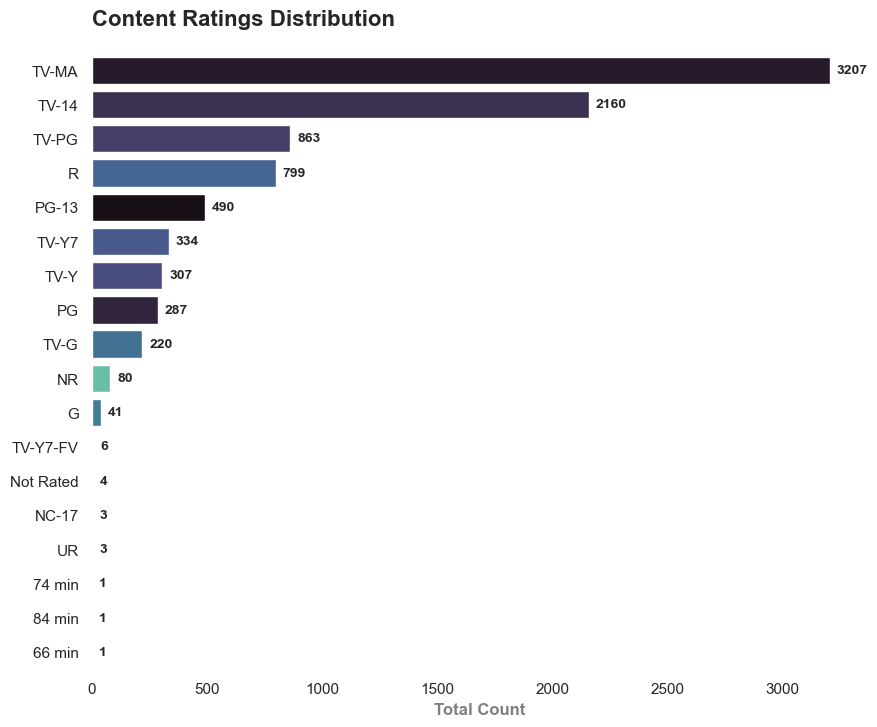

In [32]:
#Most Common Ratings
# Set size and style
plt.figure(figsize=(10, 8))
sns.set_style("white")

# Create the plot with a 'mako' gradient palette
ax = sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index, 
                   palette='mako', hue='rating', legend=False)

# Add data labels to every bar using a loop
for container in ax.containers:
    ax.bar_label(container, padding=5, fontweight='bold', fontsize=10)

# Clean up the titles and labels
plt.title("Content Ratings Distribution", fontsize=16, fontweight='bold', loc='left', pad=20)
plt.xlabel("Total Count", fontweight='bold', color='gray')
plt.ylabel("") # Removing 'rating' label as it's obvious

# Remove the frame for a modern look
sns.despine(left=True, bottom=True)
plt.show()

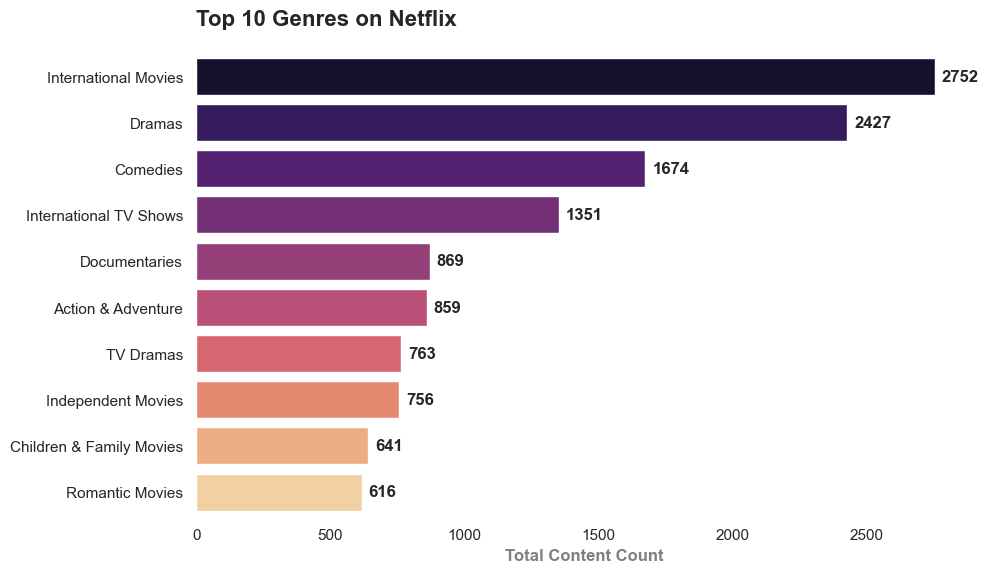

In [36]:
#Top Genres on Netflix

# 1. Clean and prepare data (strip whitespace to merge duplicates)
top_genres = df['listed_in'].str.split(',').explode().str.strip().value_counts().head(10)

# 2. Set style and plot
plt.figure(figsize=(10, 6))
sns.set_style("white")
ax = sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='magma', legend=False)

# 3. Add labels to every bar
for container in ax.containers:
    ax.bar_label(container, padding=5, fontweight='bold')

# 4. Final touches
plt.title("Top 10 Genres on Netflix", fontsize=16, fontweight='bold', loc='left', pad=20)
plt.xlabel("Total Content Count", fontweight='bold', color='gray')
plt.ylabel("") 
sns.despine(left=True, bottom=True)
plt.show()

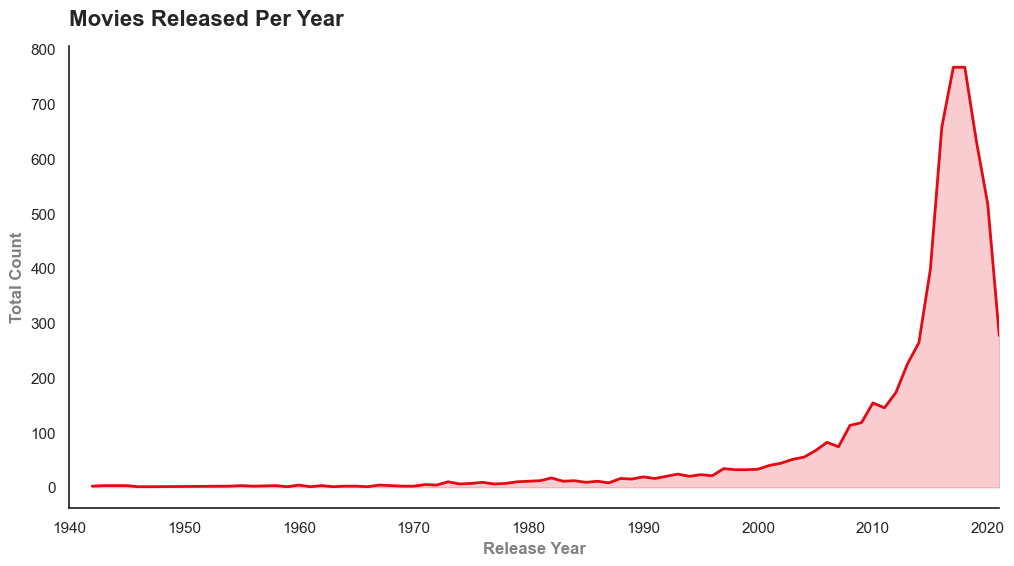

In [38]:
#Movies Released Per Year

# Prepare data (filtering for Movies only as per your title)
data = df[df['type'] == 'Movie']['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.set_style("white")

# Plot line and fill the area underneath
plt.plot(data.index, data.values, color='#E50914', linewidth=2)
plt.fill_between(data.index, data.values, color='#E50914', alpha=0.2)

# Refine labels and title
plt.title("Movies Released Per Year", fontsize=16, fontweight='bold', loc='left', pad=15)
plt.xlabel("Release Year", fontweight='bold', color='gray')
plt.ylabel("Total Count", fontweight='bold', color='gray')

# Focus the view on where the data starts to climb (optional)
plt.xlim(1940, data.index.max()) 

sns.despine()
plt.show()

In [39]:
#Analyze Movie Duration
movies = df[df['type'] == 'Movie']

In [41]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration_int'] = (
    movies['duration']
    .str.extract('(\d+)')
    .astype(float)
)

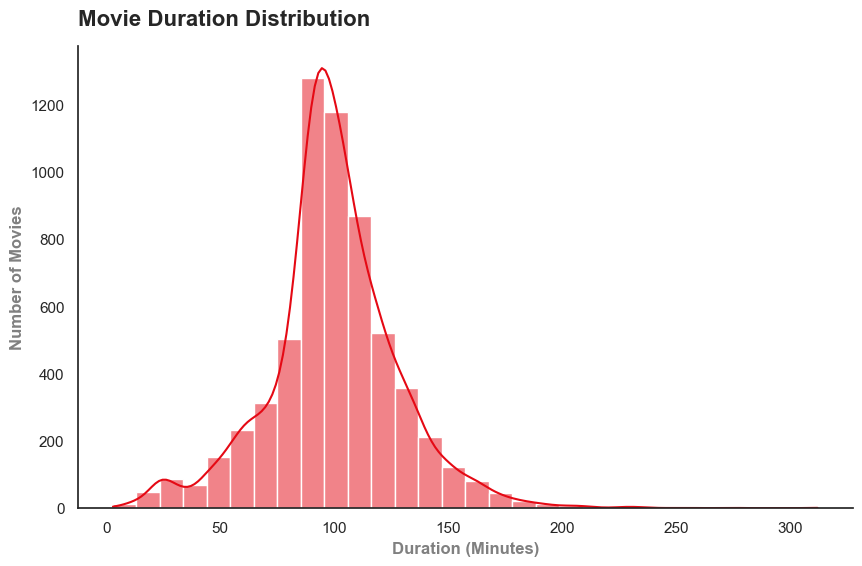

In [44]:
#Plot:
# Set style and size
plt.figure(figsize=(10, 6))
sns.set_style("white")

# Add 'kde=True' for the smooth curve and a clean color
sns.histplot(movies['duration_int'], bins=30, kde=True, color='#E50914', edgecolor='white')

# Refine labels
plt.title("Movie Duration Distribution", fontsize=16, fontweight='bold', loc='left', pad=15)
plt.xlabel("Duration (Minutes)", fontweight='bold', color='gray')
plt.ylabel("Number of Movies", fontweight='bold', color='gray')

# Remove the frame
sns.despine()
plt.show()

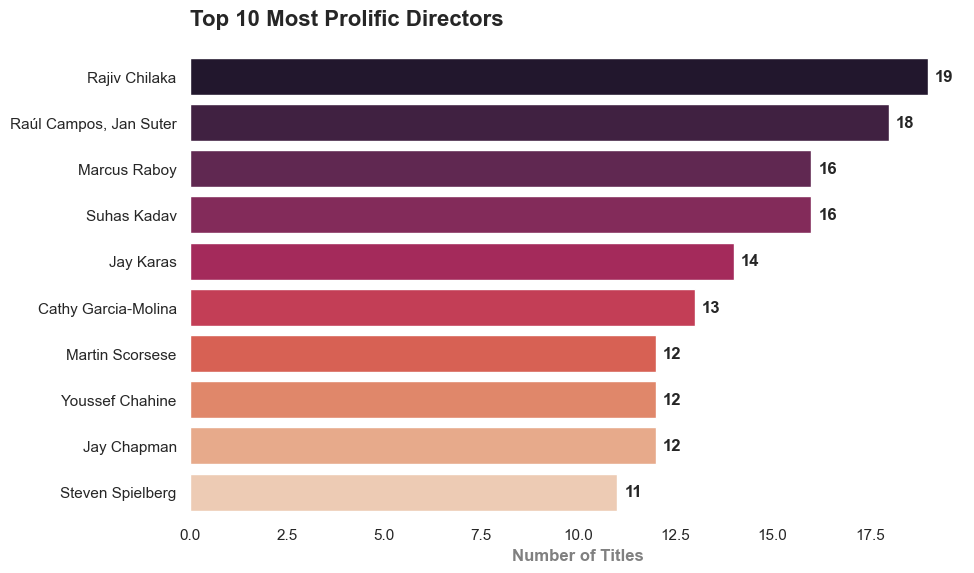

In [46]:
#Top Directors

# 1. Filter out 'Unknown' and get the top 10
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)

# 2. Set style and plot
plt.figure(figsize=(10, 6))
sns.set_style("white")
ax = sns.barplot(x=top_directors.values, y=top_directors.index, hue=top_directors.index, palette='rocket', legend=False)

# 3. Add labels to each bar
for container in ax.containers:
    ax.bar_label(container, padding=5, fontweight='bold')

# 4. Final Touches
plt.title("Top 10 Most Prolific Directors", fontsize=16, fontweight='bold', loc='left', pad=20)
plt.xlabel("Number of Titles", fontweight='bold', color='gray')
plt.ylabel("")
sns.despine(left=True, bottom=True)
plt.show()

In [47]:
#Find Oldest Movies
df.sort_values(by='release_year').head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
4250,s4251,TV Show,Pioneers: First Women Filmmakers*,Unknown,Unknown,Unknown,2018-12-30,1925,TV-14,1 Season,TV Shows,This collection restores films from women who ...,2018.0
7790,s7791,Movie,Prelude to War,Frank Capra,Unknown,United States,2017-03-31,1942,TV-14,52 min,"Classic Movies, Documentaries",Frank Capra's documentary chronicles the rise ...,2017.0
8205,s8206,Movie,The Battle of Midway,John Ford,"Henry Fonda, Jane Darwell",United States,2017-03-31,1942,TV-14,18 min,"Classic Movies, Documentaries",Director John Ford captures combat footage of ...,2017.0
8660,s8661,Movie,Undercover: How to Operate Behind Enemy Lines,John Ford,Unknown,United States,2017-03-31,1943,TV-PG,61 min,"Classic Movies, Documentaries",This World War II-era training film dramatizes...,2017.0
8739,s8740,Movie,Why We Fight: The Battle of Russia,"Frank Capra, Anatole Litvak",Unknown,United States,2017-03-31,1943,TV-PG,82 min,Documentaries,This installment of Frank Capra's acclaimed do...,2017.0
8763,s8764,Movie,WWII: Report from the Aleutians,John Huston,Unknown,United States,2017-03-31,1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...,2017.0
8640,s8641,Movie,Tunisian Victory,"Frank Capra, John Huston, Hugh Stewart, Roy Bo...",Burgess Meredith,"United States, United Kingdom",2017-03-31,1944,TV-14,76 min,"Classic Movies, Documentaries",British and American troops join forces to lib...,2017.0
8436,s8437,Movie,The Negro Soldier,Stuart Heisler,Unknown,United States,2017-03-31,1944,TV-14,40 min,"Classic Movies, Documentaries",This documentary urged African Americans to en...,2017.0
8419,s8420,Movie,The Memphis Belle: A Story of a\nFlying Fortress,William Wyler,Unknown,United States,2017-03-31,1944,TV-PG,40 min,"Classic Movies, Documentaries",This documentary centers on the crew of the B-...,2017.0
7930,s7931,Movie,San Pietro,John Huston,Unknown,United States,2017-03-31,1945,TV-14,32 min,"Classic Movies, Documentaries","After the Allies invade Italy, the Liri Valley...",2017.0


In [48]:
#Search Any Movie
df[df['title'].str.contains('Batman', case=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
1845,s1846,Movie,Batman: The Killing Joke,Sam Liu,"Kevin Conroy, Mark Hamill, Tara Strong, Ray Wi...",United States,2020-10-15,2016,R,77 min,Action & Adventure,The Joker makes life hell for the Gordon famil...,2020.0
4138,s4139,Movie,Lego DC Comics: Batman Be-Leaguered,Rick Morales,"Dee Bradley Baker, Troy Baker, John DiMaggio, ...",United States,2019-02-01,2014,TV-Y7,22 min,Movies,When Superman and the other Justice League sup...,2019.0


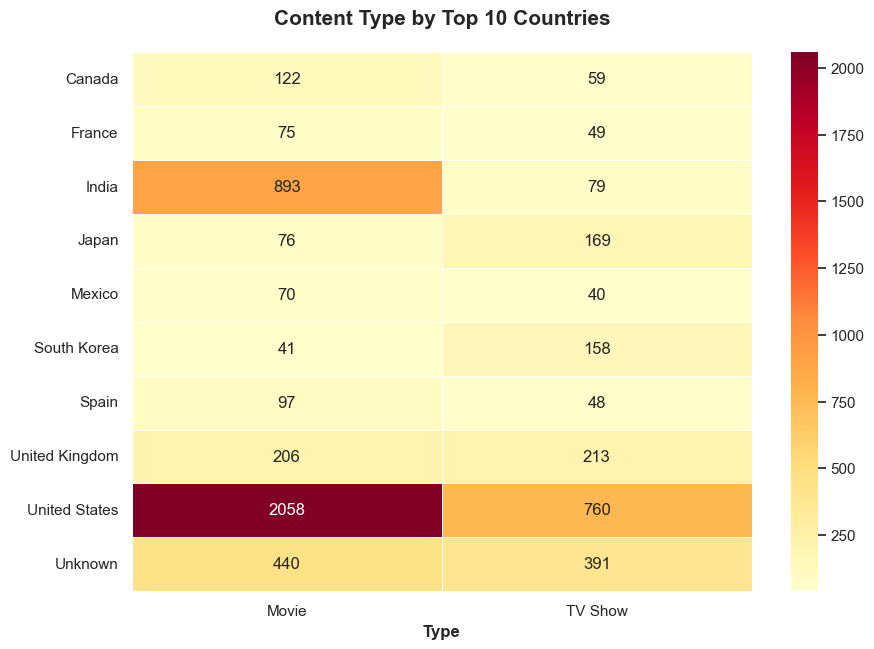

In [50]:
#Country vs Rating Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for the top 10 countries so the labels are clean
top_10_countries = df['country'].value_counts().head(10).index
df_top = df[df['country'].isin(top_10_countries)]

# 2. Create the crosstab
pivot = pd.crosstab(df_top['country'], df_top['type'])

# 3. Plot with annotations and a better color map
plt.figure(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5)

plt.title("Content Type by Top 10 Countries", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Type", fontweight='bold')
plt.ylabel("") # Removing 'country' label for a cleaner look
plt.show()

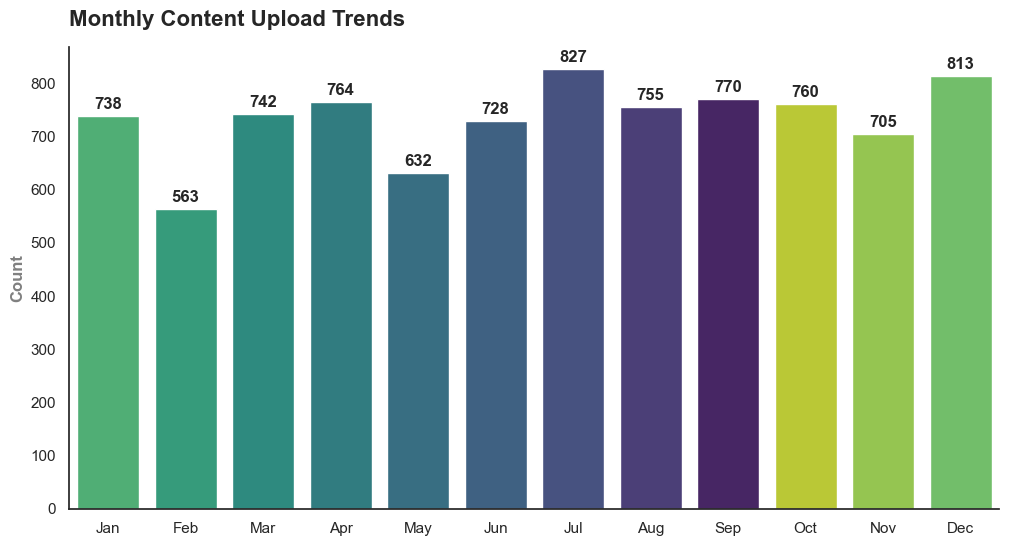

In [52]:
#Monthly Upload Trend

# 1. Map numbers to month names
month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 
             7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
df['month_name'] = df['month_added'].map(month_map)

# 2. Set style and plot
plt.figure(figsize=(12, 6))
sns.set_style("white")
ax = sns.countplot(x='month_name', data=df, order=month_map.values(), 
                   palette='viridis', hue='month_name', legend=False)

# 3. Add labels to every bar
for container in ax.containers:
    ax.bar_label(container, padding=3, fontweight='bold')

# 4. Clean up
plt.title("Monthly Content Upload Trends", fontsize=16, fontweight='bold', loc='left', pad=15)
plt.xlabel("") # Remove 'month_name' label for cleanliness
plt.ylabel("Count", fontweight='bold', color='gray')
sns.despine()
plt.show()

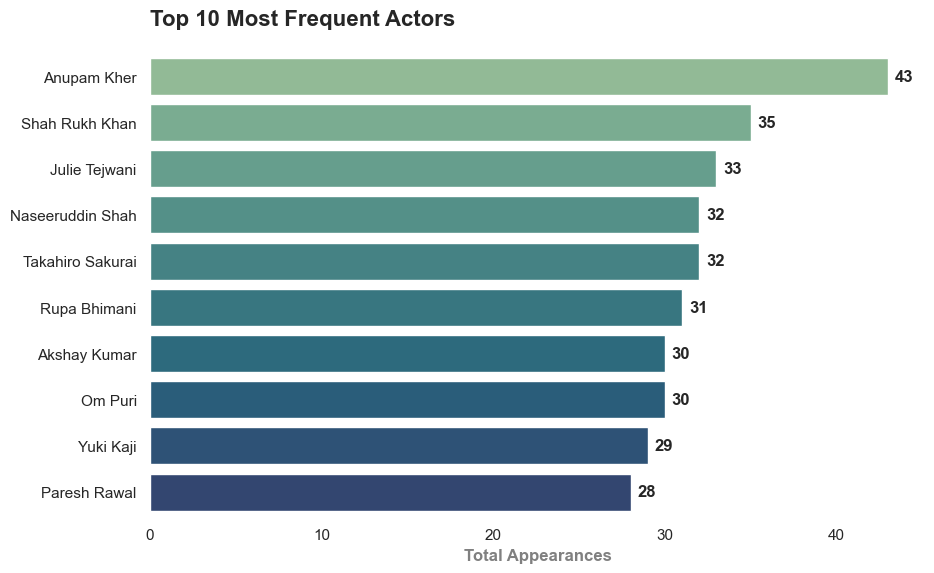

In [54]:
#Most Frequent Actors

# 1. Clean data: split, explode to rows, strip spaces, and remove 'Unknown'
top_actors = df['cast'].str.split(',').explode().str.strip()
top_actors = top_actors[top_actors != 'Unknown'].value_counts().head(10)

# 2. Set style and plot
plt.figure(figsize=(10, 6))
sns.set_style("white")
ax = sns.barplot(x=top_actors.values, y=top_actors.index, hue=top_actors.index, palette='crest', legend=False)

# 3. Add labels to every bar
for container in ax.containers:
    ax.bar_label(container, padding=5, fontweight='bold')

# 4. Final touches
plt.title("Top 10 Most Frequent Actors", fontsize=16, fontweight='bold', loc='left', pad=20)
plt.xlabel("Total Appearances", fontweight='bold', color='gray')
plt.ylabel("") 
sns.despine(left=True, bottom=True)
plt.show()